In [27]:
import matplotlib.pyplot as plt
import mplhep as hep
import uproot
import glob
import plot_utils
import numpy as np
from matplotlib import ticker

plt.rcParams['figure.dpi'] = 70
plt.style.use(hep.style.CMS)
hep.style.use("CMS")

In [6]:
cards_dir = "../cards/WH_2_6_agnostic/"
cards = glob.glob(cards_dir + "/*.nT*.root")

In [14]:
limits = {}
for card in cards:
    with uproot.open(card) as f:
        data = f["limit"]["limit"].array()
    ntracks = int(card.split(".root")[0].split(".nT")[-1])
    limits[ntracks] = data

In [15]:
limits

{30: <Array [2.7e+03, 3.56e+03, ... 4.38e+03] type='6 * float64'>,
 40: <Array [233, 306, 420, 577, 746, 372] type='6 * float64'>,
 50: <Array [40.6, 53.4, 73.2, 101, 132, 71.2] type='6 * float64'>,
 60: <Array [10.3, 13.6, 18.6, 25.3, 33.4, 17.1] type='6 * float64'>,
 80: <Array [0.563, 0.998, 1.92, ... 5.81, 1.92] type='6 * float64'>}

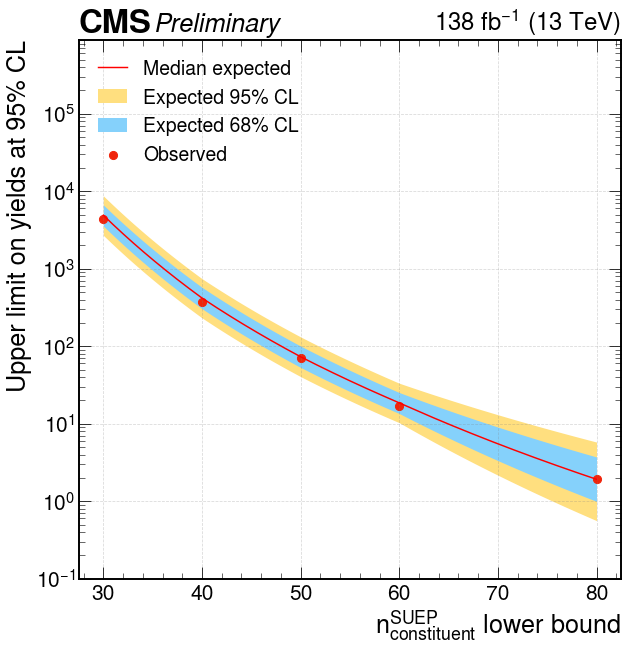

In [43]:
def plot_agnostic_limits():

    fig = plt.figure(figsize=(10,10))
    ax = fig.subplots()

    ntracks = list(limits.keys())
    xvar = np.linspace(min(ntracks),max(ntracks),1000)

    _exp = [limit[2] for limit in limits.values()]
    _s1p = [limit[1] for limit in limits.values()]
    _s1m = [limit[3] for limit in limits.values()]
    _s2p = [limit[0] for limit in limits.values()]
    _s2m = [limit[4] for limit in limits.values()]
    _obs = [limit[5] for limit in limits.values()]

    # Define interpolation
    exp_limit = plot_utils.log_interp1d(ntracks, _exp) 
    s1p_limit = plot_utils.log_interp1d(ntracks, _s1p)
    s1m_limit = plot_utils.log_interp1d(ntracks, _s1m)
    s2p_limit = plot_utils.log_interp1d(ntracks, _s2p)
    s2m_limit = plot_utils.log_interp1d(ntracks, _s2m)
    obs_limit = plot_utils.log_interp1d(ntracks, _obs)

    #Plot expected limits including brazil bands
    ax.plot(xvar, exp_limit(xvar), ls="-", ms=12, color='red', label="Median expected")
    ax.fill_between(xvar, s2m_limit(xvar), s2p_limit(xvar), color="#FFDF7Fff", lw=0, label="Expected 95% CL")
    ax.fill_between(xvar, s1m_limit(xvar), s1p_limit(xvar), color="#85D1FBff", lw=0, label="Expected 68% CL")

    # Plot observed limits
    ax.scatter(ntracks, _obs, marker='o', s=70, color='#F0240Bff', label="Observed") 
    #ax.plot(xvar,obs_limit(xvar),"-", ms=12, color='black')
    
    # Just to make everything look nice
    ax.set_ylabel(r"Upper limit on yields at 95% CL")
    ax.set_xlabel(r"$n^{\mathrm{SUEP}}_{\mathrm{constituent}}$ lower bound") 
    ax.legend(loc="upper left", fontsize=20)
    
    hep.cms.label(data=True, llabel="Preliminary", lumi=plot_utils.lumis['combined'], ax=ax) # To add CMS lumi scripts

    ax.grid(visible=True, which='major', color='grey', linestyle='--', alpha=0.3)
    ax.set_ylim(1e-1, 9e5)
    ax.set_yscale("log")
    
    y_major = ticker.LogLocator(base = 10.0, numticks = 20)
    ax.yaxis.set_major_locator(y_major)
    y_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 100)
    ax.yaxis.set_minor_locator(y_minor)
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

plot_agnostic_limits()